# Complete Linear & Polynomial Regression Task – Cancer Mortality Dataset 2020-2024

In [1]:
# importt liberaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import PolynomialFeatures

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [10]:
df = pd.read_csv("cancer_reg.csv")
df.head()

,FIPSN,NAME,STUSPS,All_Malignant_Cancers_Rate,All_Malignant_Cancers_SE,All_Malignant_Cancers_Lwr_CI,All_Malignant_Cancers_Upr_CI,All_Malignant_Cancers_Count,All_Malignant_Cancers_Pop,Bladder_Rate,...,T070_C00003_B_A999_count,T070_C00003_B_A999_denom,T070_C00104_B_A001_calc,T070_C00104_B_A001_count,T070_C00104_B_A001_denom,T070_C00105_B_A001_calc,T070_C00105_B_A001_count,T070_C00105_B_A001_denom,Description,Is_Rural
0,1053,Escambia,AL,190.0,8.9,173.0,208.3,479.0,183147,NaN,...,6955,36629,49.1,17970,36629,50.9,18659,36629,"Nonmetro - Urban population of 5,000 to 20,000...",Rural
1,1129,Washington,AL,159.4,12.4,136.1,185.9,178.0,75713,NaN,...,3184,15143,50.2,7604,15143,49.8,7539,15143,"Nonmetro - Urban population of fewer than 5,00...",Rural
2,1113,Russell,AL,205.7,8.0,190.3,221.9,705.0,294054,5.1,...,8979,58811,47.6,27973,58811,52.4,30838,58811,"Metro - Counties in metro areas of 250,000 to ...",Urban
3,1107,Pickens,AL,173.0,11.6,151.0,197.7,236.0,93606,NaN,...,3723,18721,50.5,9446,18721,49.5,9275,18721,"Metro - Counties in metro areas of 250,000 to ...",Urban
4,1119,Sumter,AL,134.9,14.2,108.4,166.2,106.0,59390,NaN,...,2354,11878,44.3,5266,11878,55.7,6612,11878,"Nonmetro - Urban population of fewer than 5,00...",Rural


In [ ]:
# . Rename target column
df.rename(columns={"All_Malignant_Cancers_Rate": "TARGET_deathRate"},inplace=True)

In [12]:
# Rename demographic columns
df.rename(columns={

    "T070_C00024_B_A001_calc":
        "Asian_Pacific_Islander_Percent",

    "T070_C00026_B_A001_calc":
        "Hispanic_Percent",

    "T070_C00022_B_A001_calc":
        "Black_Percent",

    "T070_C00002_B_A999_calc":
        "Under18_Percent",

    "T070_C00023_B_A001_calc":
        "American_Indian_Alaska_Native_Percent",

    "T070_C00025_B_A001_calc":
        "White_Percent",

    "T070_C00102_B_A999_calc":
        "Age18_39_Percent",

    "T070_C00028_B_A999_calc":
        "Age40_Over_Percent",

    "T070_C00103_B_A999_calc":
        "Age40_64_Percent",

    "T070_C00029_B_A999_calc":
        "Age50_Over_Percent",

    "T070_C00003_B_A999_calc":
        "Age65_Over_Percent",

    "T070_C00104_B_A001_calc":
        "Male_Percent",

    "T070_C00105_B_A001_calc":
        "Female_Percent"

}, inplace=True)

In [14]:
df.head()

,FIPSN,NAME,STUSPS,TARGET_deathRate,All_Malignant_Cancers_SE,All_Malignant_Cancers_Lwr_CI,All_Malignant_Cancers_Upr_CI,All_Malignant_Cancers_Count,All_Malignant_Cancers_Pop,Bladder_Rate,...,T070_C00003_B_A999_count,T070_C00003_B_A999_denom,Male_Percent,T070_C00104_B_A001_count,T070_C00104_B_A001_denom,Female_Percent,T070_C00105_B_A001_count,T070_C00105_B_A001_denom,Description,Is_Rural
0,1053,Escambia,AL,190.0,8.9,173.0,208.3,479.0,183147,NaN,...,6955,36629,49.1,17970,36629,50.9,18659,36629,"Nonmetro - Urban population of 5,000 to 20,000...",Rural
1,1129,Washington,AL,159.4,12.4,136.1,185.9,178.0,75713,NaN,...,3184,15143,50.2,7604,15143,49.8,7539,15143,"Nonmetro - Urban population of fewer than 5,00...",Rural
2,1113,Russell,AL,205.7,8.0,190.3,221.9,705.0,294054,5.1,...,8979,58811,47.6,27973,58811,52.4,30838,58811,"Metro - Counties in metro areas of 250,000 to ...",Urban
3,1107,Pickens,AL,173.0,11.6,151.0,197.7,236.0,93606,NaN,...,3723,18721,50.5,9446,18721,49.5,9275,18721,"Metro - Counties in metro areas of 250,000 to ...",Urban
4,1119,Sumter,AL,134.9,14.2,108.4,166.2,106.0,59390,NaN,...,2354,11878,44.3,5266,11878,55.7,6612,11878,"Nonmetro - Urban population of fewer than 5,00...",Rural


# EDA

In [15]:
df.shape

(3142, 177)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3142 entries, 0 to 3141
Columns: 177 entries, FIPSN to Is_Rural
dtypes: float64(123), int64(50), object(4)
memory usage: 4.2+ MB


In [17]:
df.describe()

,FIPSN,TARGET_deathRate,All_Malignant_Cancers_SE,All_Malignant_Cancers_Lwr_CI,All_Malignant_Cancers_Upr_CI,All_Malignant_Cancers_Count,All_Malignant_Cancers_Pop,Bladder_Rate,Bladder_SE,Bladder_Lwr_CI,...,T070_C00029_B_A999_denom,Age65_Over_Percent,T070_C00003_B_A999_count,T070_C00003_B_A999_denom,Male_Percent,T070_C00104_B_A001_count,T070_C00104_B_A001_denom,Female_Percent,T070_C00105_B_A001_count,T070_C00105_B_A001_denom
count,3142.000000,3084.000000,3084.000000,3084.000000,3084.000000,3084.000000,3.142000e+03,1052.000000,1052.000000,1052.000000,...,3.142000e+03,3142.000000,3.142000e+03,3.142000e+03,3142.000000,3.142000e+03,3.142000e+03,3142.000000,3.142000e+03,3.142000e+03
mean,30383.649268,162.430058,11.145266,141.637646,187.266407,988.521401,5.329765e+05,4.750951,0.809125,3.314449,...,1.065953e+05,20.440420,1.834298e+04,1.065953e+05,50.437142,5.277149e+04,1.065953e+05,49.562858,5.382383e+04,1.065953e+05
std,15162.508374,29.098377,7.573745,27.534733,38.822185,2594.195724,1.677429e+06,1.314245,0.415806,0.853303,...,3.354864e+05,5.080116,5.236719e+04,3.354864e+05,2.577127,1.656950e+05,3.354864e+05,2.577127,1.698303e+05,3.354864e+05
min,1001.000000,59.900000,0.500000,44.600000,79.300000,16.000000,2.640000e+02,2.000000,0.100000,1.300000,...,3.300000e+01,4.500000,1.400000e+01,3.300000e+01,39.400000,2.700000e+01,3.300000e+01,18.200000,6.000000e+00,3.300000e+01
25%,18177.500000,144.000000,5.800000,126.100000,161.800000,141.000000,5.405100e+04,3.900000,0.500000,2.700000,...,1.081050e+04,17.225000,2.269000e+03,1.081050e+04,49.200000,5.469250e+03,1.081050e+04,49.000000,5.307000e+03,1.081050e+04
50%,29176.000000,160.800000,9.600000,142.600000,182.500000,327.500000,1.298030e+05,4.500000,0.800000,3.300000,...,2.596050e+04,20.000000,5.153500e+03,2.596050e+04,50.000000,1.307300e+04,2.596050e+04,50.000000,1.287350e+04,2.596050e+04
75%,45080.500000,179.300000,14.500000,158.500000,207.525000,795.750000,3.443665e+05,5.400000,1.100000,3.900000,...,6.887300e+04,22.900000,1.340800e+04,6.887300e+04,51.000000,3.486075e+04,6.887300e+04,50.800000,3.463425e+04,6.887300e+04
max,56045.000000,424.800000,63.400000,384.100000,468.800000,72469.000000,4.904334e+07,13.800000,3.200000,8.200000,...,9.808667e+06,81.800000,1.487700e+06,9.808667e+06,81.800000,4.857636e+06,9.808667e+06,60.600000,4.951031e+06,9.808667e+06


In [18]:
df.isnull().sum()

FIPSN                        0
NAME                         0
STUSPS                       0
TARGET_deathRate            58
All_Malignant_Cancers_SE    58
                            ..
Female_Percent               0
T070_C00105_B_A001_count     0
T070_C00105_B_A001_denom     0
Description                  0
Is_Rural                     0
Length: 177, dtype: int64

In [20]:
df["TARGET_deathRate"].describe()

count    3084.000000
mean      162.430058
std        29.098377
min        59.900000
25%       144.000000
50%       160.800000
75%       179.300000
max       424.800000
Name: TARGET_deathRate, dtype: float64

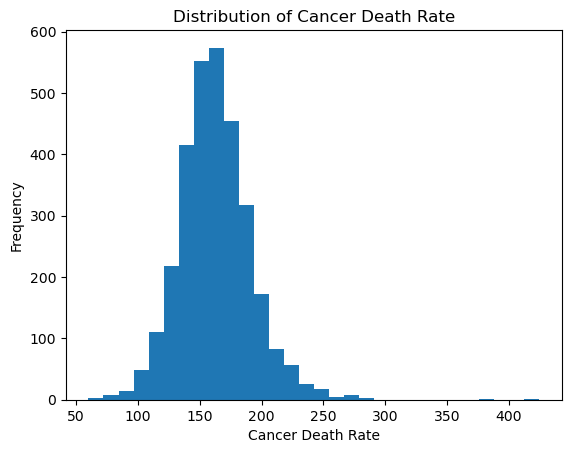

In [21]:
# Target distribution
plt.hist(
    df["TARGET_deathRate"].dropna(),
    bins=30
)

plt.xlabel("Cancer Death Rate")
plt.ylabel("Frequency")
plt.title("Distribution of Cancer Death Rate")

plt.show()

# Correlation

In [22]:
demographic_columns = [

    "Asian_Pacific_Islander_Percent",
    "Hispanic_Percent",
    "Black_Percent",
    "Under18_Percent",
    "American_Indian_Alaska_Native_Percent",
    "White_Percent",
    "Age18_39_Percent",
    "Age40_Over_Percent",
    "Age40_64_Percent",
    "Age50_Over_Percent",
    "Age65_Over_Percent",
    "Male_Percent",
    "Female_Percent"
]

In [23]:
# Correlation with cancer mortality
correlation_data = df[
    demographic_columns + ["TARGET_deathRate"]
]

correlation_data.corr()["TARGET_deathRate"].sort_values(
    ascending=False
)

TARGET_deathRate                         1.000000
Black_Percent                            0.179024
Under18_Percent                          0.142621
American_Indian_Alaska_Native_Percent    0.101964
Age40_64_Percent                         0.049247
White_Percent                            0.032522
Female_Percent                           0.003056
Male_Percent                            -0.003056
Age50_Over_Percent                      -0.013130
Age40_Over_Percent                      -0.022929
Age65_Over_Percent                      -0.057068
Age18_39_Percent                        -0.073886
Hispanic_Percent                        -0.215188
Asian_Pacific_Islander_Percent          -0.284968
Name: TARGET_deathRate, dtype: float64

# Feature Selection

In [24]:
features = [
    "Age18_39_Percent",
    "Age40_Over_Percent",
    "Age40_64_Percent",
    "Age50_Over_Percent",
    "Age65_Over_Percent",
    "Male_Percent",
    "Female_Percent"
]

In [25]:
X = df[features].copy()

y = df["TARGET_deathRate"].copy()

# Missing Values

In [28]:
# Convert to numeric
X = X.apply(pd.to_numeric,errors="coerce")

y = pd.to_numeric(y,errors="coerce")

In [29]:
# Remove rows with missing target
valid_rows = y.notna()

X = X.loc[valid_rows]

y = y.loc[valid_rows]

In [30]:
# Fill missing feature values
X = X.fillna(X.mean())

# Train-Test Split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

print("Training Data =", X_train.shape)

print("Testing Data =", X_test.shape)

Training Data = (2467, 7)
Testing Data = (617, 7)


# Linear Regression

In [ ]:
# Create model
linear_model = LinearRegression()

# Train model
linear_model.fit( X_train, y_train)

# Prediction
y_pred_linear = linear_model.predict(X_test)

# Linear Regression Evaluation
# MAE
mae_linear = mean_absolute_error(y_test,y_pred_linear)
print("mae_linear:",mae_linear )

# MSE
mse_linear = mean_squared_error(y_test,y_pred_linear)
print("mse_linear:",mse_linear)

# RMSE
rmse_linear = np.sqrt(mse_linear)
print("rmse_linear:",rmse_linear)

# R² Score
r2_linear = r2_score(y_test,y_pred_linear)
print("r2_linear:",r2_linear)



mae_linear: 20.555080324269696
mse_linear: 685.3763494124962
rmse_linear: 26.179693455281257
r2_linear: 0.04977708812111792


# Polynomial Regression Degree 2

In [42]:
# Create polynomial features
poly2 = PolynomialFeatures(degree=2,include_bias=False)

X_train_poly2 = poly2.fit_transform(X_train)

X_test_poly2 = poly2.transform(X_test)

In [44]:
# Create model
poly_model2 = LinearRegression()

# Train Model
poly_model2.fit(X_train_poly2,y_train)

# Prediction
y_pred_poly2 = poly_model2.predict(X_test_poly2)

# Evaluation
mae_poly2 = mean_absolute_error(y_test,y_pred_poly2)
print("MAE =", mae_poly2)

mse_poly2 = mean_squared_error(y_test,y_pred_poly2)
print("MSE =", mse_poly2)

rmse_poly2 = np.sqrt(mse_poly2)
print("rmse =", rmse_poly2)

r2_poly2 = r2_score(y_test,y_pred_poly2)
print("R2 Score =", r2_poly2)

MAE = 20.069873421766154
MSE = 662.9292871517712
rmse = 25.747413212821424
R2 Score = 0.08089825663356587


# Polynomial Regression Degree 3

In [45]:
# Polynomial Regression Degree 3
poly3 = PolynomialFeatures(degree=3,include_bias=False)

X_train_poly3 = poly3.fit_transform(X_train)

X_test_poly3 = poly3.transform(X_test)

# Create model
poly_model3 = LinearRegression()

# Train model
poly_model3.fit(X_train_poly3,y_train)

# Prediction
y_pred_poly3 = poly_model3.predict(X_test_poly3)

# Evaluation
mae_poly3 = mean_absolute_error(y_test,y_pred_poly3)
print("MAE =", mae_poly3)

mse_poly3 = mean_squared_error(y_test,y_pred_poly3)
print("MSE =", mse_poly3)


rmse_poly3 = np.sqrt(mse_poly3)

print("RMSE =", rmse_poly3)


r2_poly3 = r2_score(y_test,y_pred_poly3)
print("R2 Score =", r2_poly3)


MAE = 19.90947204727239
MSE = 722.7563711549461
RMSE = 26.884128610668157
R2 Score = -0.00204750888555405


# Compare Models

In [48]:
# Comparison table
result = pd.DataFrame({

    "Model": ["Linear Regression","Polynomial Degree 2","Polynomial Degree 3"],

    "MAE": [mae_linear,mae_poly2,mae_poly3],

    "MSE": [mse_linear,mse_poly2,mse_poly3],

    "RMSE": [rmse_linear,rmse_poly2,rmse_poly3],

    "R2 Score": [ r2_linear, r2_poly2, r2_poly3]})
result

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,20.555080,685.376349,26.179693,0.049777
1,Polynomial Degree 2,20.069873,662.929287,25.747413,0.080898
2,Polynomial Degree 3,19.909472,722.756371,26.884129,-0.002048


Linear Regression and Polynomial Regression of degree 2 and degree 3 were used to predict TARGET_deathRate. The models were evaluated using MAE, MSE, RMSE and R² score. Lower MAE, MSE and RMSE values indicate lower prediction error, while a higher R² value indicates better model performance. Polynomial Regression can capture nonlinear relationships in the data; however, increasing the polynomial degree may increase model complexity and may lead to overfitting.

# Actual vs Predicted

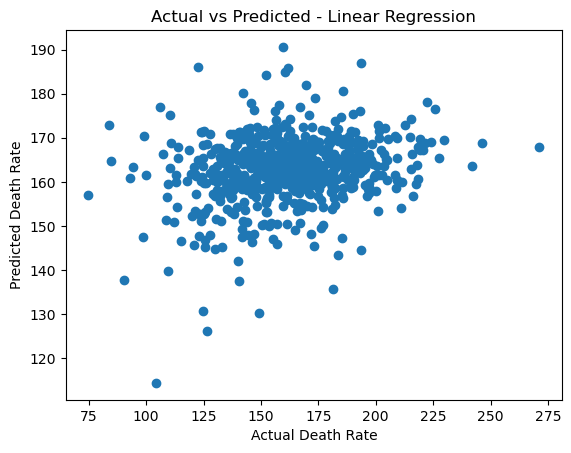

In [61]:
# Linear Regression
plt.scatter( y_test, y_pred_linear)

plt.xlabel("Actual Death Rate")

plt.ylabel("Predicted Death Rate")

plt.title("Actual vs Predicted - Linear Regression")

plt.show()

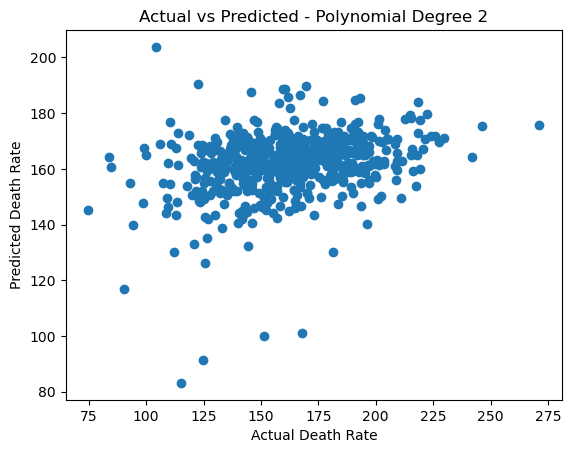

In [59]:
# Polynomial Degree 2
plt.scatter(y_test,y_pred_poly2)

plt.xlabel("Actual Death Rate")

plt.ylabel("Predicted Death Rate")

plt.title("Actual vs Predicted - Polynomial Degree 2")

plt.show()

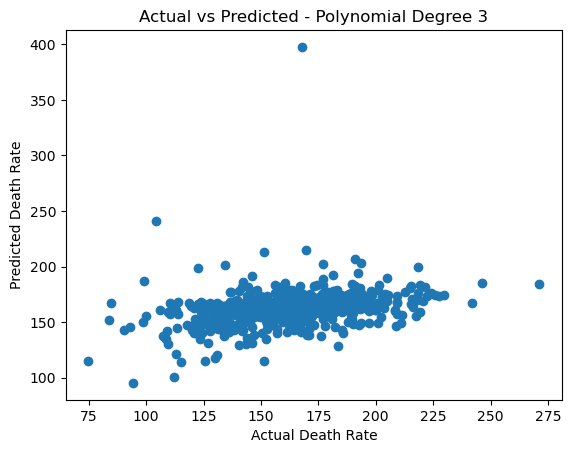

In [60]:
# Polynomial Degree 3
plt.scatter(y_test,y_pred_poly3)

plt.xlabel("Actual Death Rate")

plt.ylabel("Predicted Death Rate")

plt.title("Actual vs Predicted - Polynomial Degree 3")

plt.show()

# Residual Plot

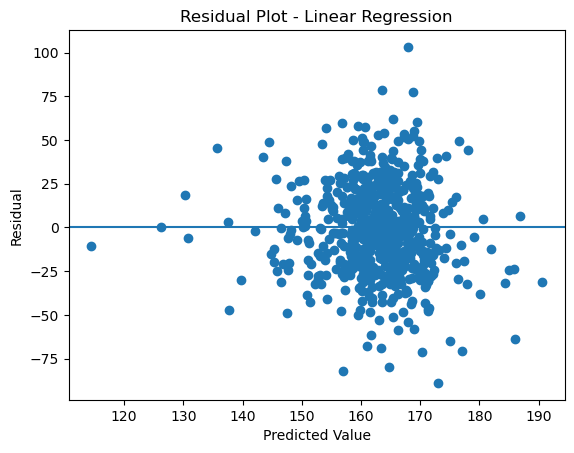

In [52]:
# Linear Regression residual
residual = (y_test - y_pred_linear)

plt.scatter(y_pred_linear,residual)

plt.axhline( y=0)

plt.xlabel("Predicted Value")

plt.ylabel("Residual")

plt.title("Residual Plot - Linear Regression")

plt.show()

